# Importing Libraries

In [26]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# Loading the saved files

In [27]:
rf_pipeline = joblib.load("../results/random_forest_pipeline.pkl")
X_test = joblib.load("../results/X_test.pkl")
y_test = joblib.load("../results/y_test.pkl")

# Extracting Model Parts

In [28]:
preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["classifier"]

# Transforming the dataset

In [29]:
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(X_test_transformed.shape)
print(len(feature_names))

(6033, 104)
104


# Building the SHAP Explainer

In [30]:
type(X_test_transformed)
X_test_transformed.dtype if hasattr(X_test_transformed, "dtype") else "no dtype"

import numpy as np
from scipy import sparse

# Convert sparse matrix to dense if needed
if sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

# Force numeric dtype
X_test_transformed = np.asarray(X_test_transformed, dtype=np.float64)

print(type(X_test_transformed))
print(X_test_transformed.dtype)
print(X_test_transformed.shape)

<class 'numpy.ndarray'>
float64
(6033, 104)


In [31]:
X_sample = X_test_transformed[:300]
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# Summary Plot

In [32]:
print(type(shap_values))
print(np.array(shap_values).shape)
print(X_sample.shape)
print(len(feature_names))

<class 'numpy.ndarray'>
(300, 104, 2)
(300, 104)
104


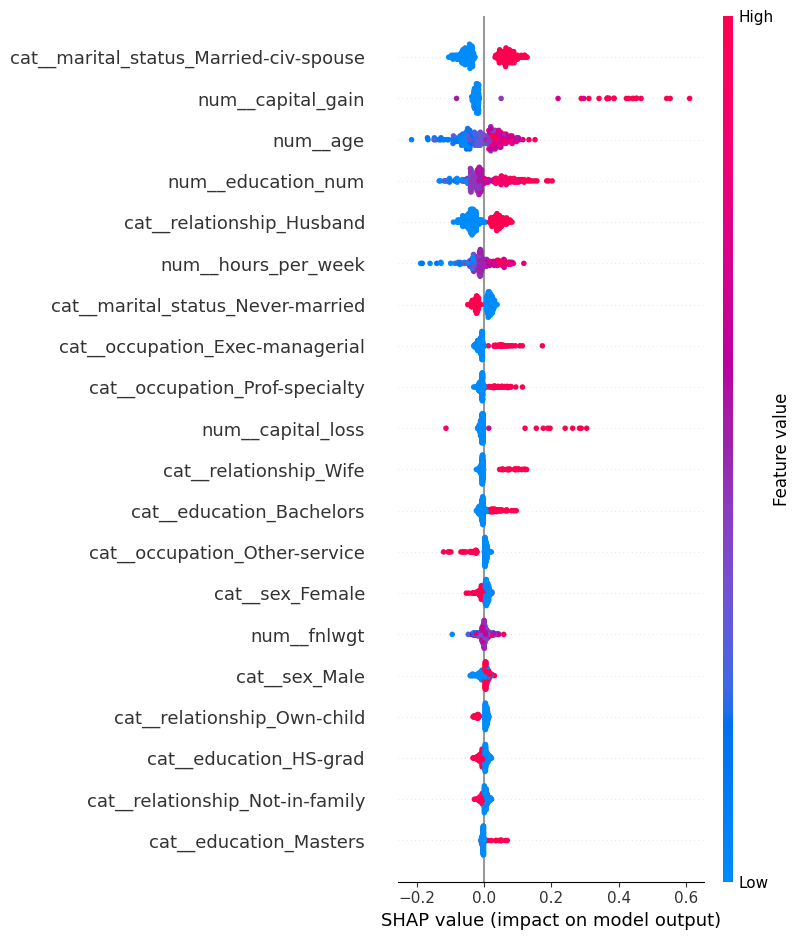

In [34]:
shap_values_class_1 = shap_values[:, :, 1]
shap.summary_plot(shap_values_class_1, X_sample, feature_names=feature_names)

# Bar Plot

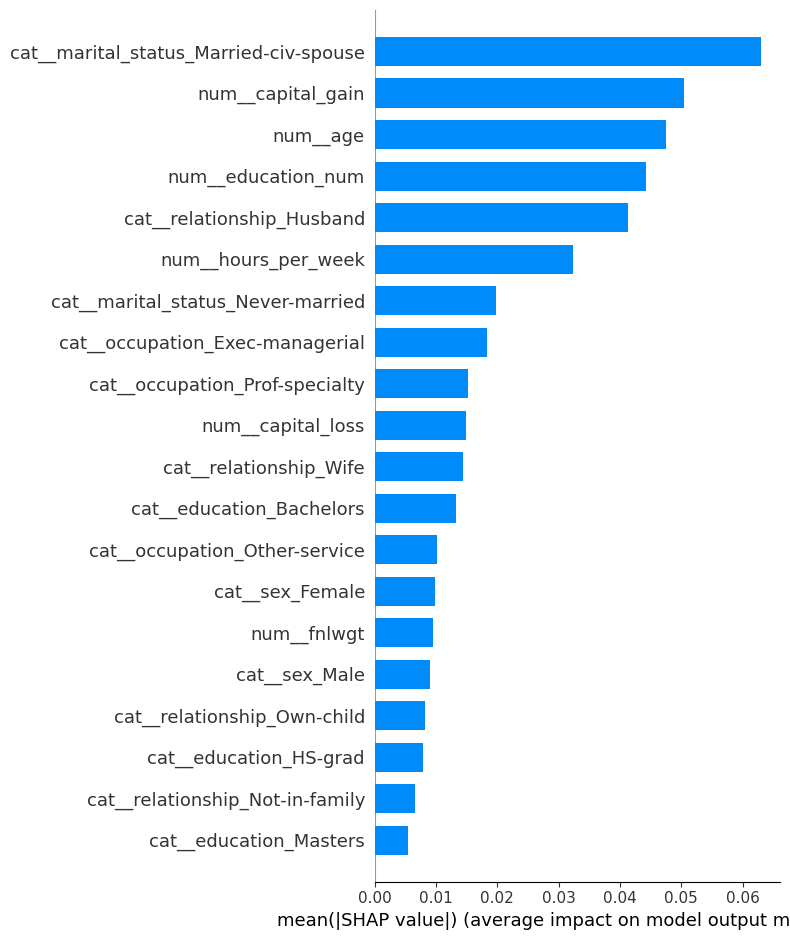

In [35]:
shap.summary_plot(shap_values_class_1, X_sample, feature_names=feature_names, plot_type="bar")

# Saving the plots

In [36]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values_class_1, X_sample, feature_names=feature_names, show=False)
plt.savefig("../figures/shap_summary.png", bbox_inches="tight", dpi=300)
plt.close()

shap.summary_plot(shap_values_class_1, X_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.savefig("../figures/shap_bar.png", bbox_inches="tight", dpi=300)
plt.close()

The SHAP analysis highlights the most influential features in the Random Forest model’s income predictions. Features such as age, education level, capital gain, and hours worked per week are expected to contribute strongly to predictions. This analysis supports the explainability objective of the study by identifying the variables driving model decisions.